In [1]:
# Training name
training_name = 'Transformer0e_2bit'

# Number of trainings to run
n_tries = 2

# Gaussian noise parameters
NOISE_MU = 0.0
NOISE_SIGMA = 0.0 # e-

# Precision of input data
N_BITS = 2

In [2]:
# IMPORTS ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import os, subprocess
from pathlib import Path
import random

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

from models import *
from plotting import *

2026-04-07 13:32:03.454814: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords"

dataset_dir_val = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val",'3sr_16x16_'+str(int(NOISE_SIGMA))+'eNoise_test')

batch_size = 5000
val_batch_size = 5000
val_file_size = len(os.listdir(dataset_dir_val))

In [4]:
def grep(string, filename):

    out_list = []

    cmd = "grep '" + string + "' " + filename
    print(cmd)
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    # Get output data
    cmd_out = result.stdout.splitlines()
    for line in cmd_out:
        print(line)
        out_list += [line.split(':')[-1].strip()]

    return out_list

In [5]:
seeds = grep('Seed','log_'+training_name+'*')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'*')
print("Fingerprints = ", fingerprints)
    
residuals = {}

# BEGIN LOOP ---------------------------------------------------------------------
for i in range(len(fingerprints)):

    base_dir = './trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
    if not os.path.exists(base_dir):
        print("Fingerprint " + fingerprints[i] + " not found")
        continue
        
    checkpoint_dir = base_dir + 'checkpoints/'
    checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
    latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)

    model = create_vit_model(input_shape=(16,16,2),   
                             patch_size=(3,4),        
                             embed_dim=64,           
                             num_heads=4,            
                             ff_dim=128,              
                             num_layers=4,            
                             dropout=0.1,        
                             n_bits=N_BITS,
                             final_outputs=14         
                            )

    print(f"Loading model from {latest_checkpoint}")
    model.load_weights(latest_checkpoint)

    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_val,
        shuffle=True,
        seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotA'] = sf[2]
    scale_factor['cotB'] = sf[3]

    df = construct_df(model, test_generator, scale_factor)
    df.to_parquet(base_dir+"residuals.parquet")
    residuals[i] = df


grep 'Seed' log_Transformer0e_2bit*
log_Transformer0e_2bit_2.txt:Seed:  646
log_Transformer0e_2bit_2.txt:Seed:  897
log_Transformer0e_2bit_9.txt:Seed:  845
Seeds =  ['646', '897', '845']
grep 'Fingerprint' log_Transformer0e_2bit*
log_Transformer0e_2bit_2.txt:Fingerprint:  31ac8cc6
log_Transformer0e_2bit_2.txt:Fingerprint:  e72e8ca9
log_Transformer0e_2bit_9.txt:Fingerprint:  5d4ba746
Fingerprints =  ['31ac8cc6', 'e72e8ca9', '5d4ba746']
Loading model from ./trained_models/model-31ac8cc6-Transformer0e_2bit-checkpoints/checkpoints/weights.5000-t-51177.56-v-52477.84.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eNoise_test/metadata.json


21/21 [==============================] - 4s 171ms/step


100%|██████████| 21/21 [00:01<00:00, 15.62it/s]


0.20174779 -0.60974187 1.0162302
Fingerprint e72e8ca9 not found
Loading model from ./trained_models/model-5d4ba746-Transformer0e_2bit-checkpoints/checkpoints/weights.372-t102921.24-v102835.76.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eNoise_test/metadata.json


21/21 [==============================] - 3s 142ms/step


100%|██████████| 21/21 [00:01<00:00, 15.85it/s]


0.20174779 -0.60974187 1.0162302


0
2


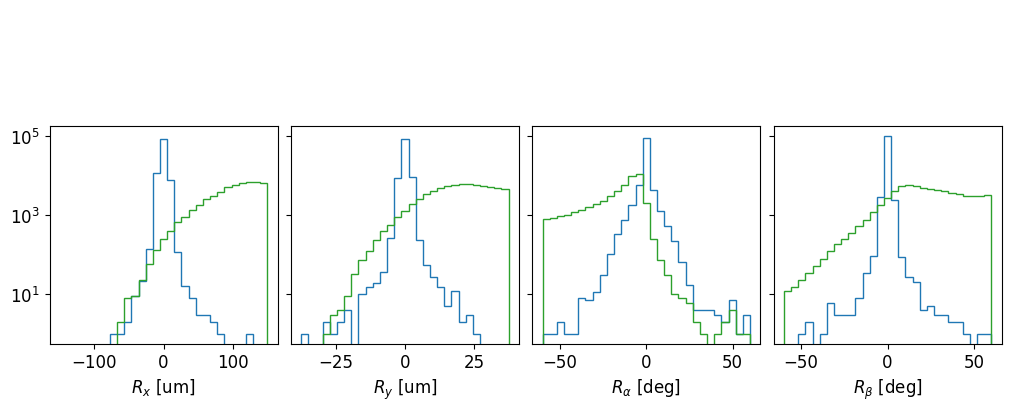

In [6]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

fig, ax = plt.subplots(2,4,figsize=(10,4),sharey='row', constrained_layout=True, gridspec_kw={'height_ratios': [1, 2]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

for i,df in residuals.items():

    print(i)

    # x
    ax[1,0].set_xlabel(r'$R_x$ [um]')
    ax[1,0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
    ax[1,0].set_yscale('log')

    # y
    ax[1,1].set_xlabel(r'$R_y$ [um]')
    ax[1,1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

    # alpha
    ax[1,2].set_xlabel(r'$R_\alpha$ [deg]')
    ax[1,2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    # beta
    ax[1,3].set_xlabel(r'$R_\beta$ [deg]')
    ax[1,3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])

#plt.tight_layout()
#plt.savefig('plots/'+training_name+'_residuals.png')